# Notebook 6: Inferens via joint sandsynligheder og diskrete SFS-observationer

I denne notebook vil jeg undersøge Bayesiansk inferens baseret på joint sandsynligheder den eksakte sandsynlighedstabel over kombinationer af diskrete mutationshændelser (singletons, doubletons osv.). Dette er anderledes fra TMRCA-inferens: i stedet for kontinuerte absorptionstider bruger jeg tælle-data om, hvilken kategori hver mutation falder i.

Via *joint_prob_graph* konstrueres en udvidet graf, der tracker alle kombinationer af diskrete hændelser (mutationer) op til en øvre grænse. Absorptionstilstandene i denne graf svarer til specifikke observationstyper, og SVGD kan da optimere mod den observerede fordelingen.

Jeg vil gerne undersøge følgende spørgsmål:

- Hvad er informationsindholdet i joint SFS frem for marginal SFS? 
- Hvornår er modellens joint-sandsynlighedstabel en god nok approksimation, og hvad er effekten af *tot_reward_limit*?

In [1]:
# Importer de nødvendige pakker 
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"   
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=1"

from phasic import (
    Graph, with_ipv,
    GaussPrior, HalfCauchyPrior, DataPrior, LogGaussPrior,
    Adam, Adamelia, Adagrad, ExpStepSize, ExpRegularization,
    StateIndexer, Property,
    clear_caches, set_log_level, model_selection
)
import numpy as np
import jax.numpy as jnp
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
from functools import partial
from itertools import combinations_with_replacement
all_pairs = partial(combinations_with_replacement, r=2)
%config InlineBackend.figure_format = 'svg'

np.random.seed(42)
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (10, 4)

clear_caches()

# Hjælpefunktion til sampling af joint-observationer
def sample_joint_observations(joint_prob_graph, theta, nr_observations=1000):
    joint_prob_graph.update_weights(theta)
    table = joint_prob_graph.joint_prob_table()
    p = table['prob'] / table['prob'].sum()
    idx = np.random.choice(table.index.values, nr_observations, p=p.to_numpy())
    return table.loc[idx, table.columns[:-1]].to_numpy().tolist()

print("Setup færdig.")

# Standard SVGD-konfiguration fra NB02 
OPTIMIZER    = Adamelia(0.2)
N_PART_TEST  = 20
N_ITER_1P    = 300
N_ITER_2P    = 400
N_OBS_STD    = 3000
MU_STD       = 1.0
TOT_REW_LIM  = 3

  Removed 17 file(s), preserved directory structure
Setup færdig.


In [2]:
import vscodenb
vscodenb.is_vscode_dark_theme = lambda: (False, 'white')

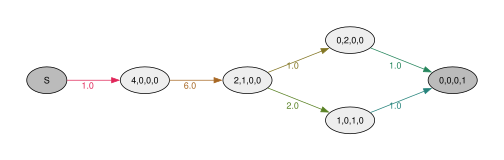

In [3]:
# Standard coalescent med StateIndexer 
nr_samples = 4
indexer = StateIndexer(
    lineage=[Property('descendants', min_value=1, max_value=nr_samples)]
)

@with_ipv([nr_samples]+[0]*(nr_samples-1))
def coalescent_1param(state):
    transitions = []
    for i, j in all_pairs(indexer.lineage):
        p1 = indexer.lineage.index_to_props(i)
        p2 = indexer.lineage.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy()
        new[i] -= 1; new[j] -= 1
        k = indexer.lineage.props_to_index(descendants=p1.descendants+p2.descendants)
        new[k] += 1
        transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph = Graph(coalescent_1param)
graph.plot()

## Validering og data fra msprime

1. Simuler ancestral recombination graph med msprime.sim_ancestry
2. Tilføj mutationer med msprime.sim_mutations
3. For hvert tree: tæl mutationer per frekvensklasse (SFS-observationer)
4. Filtrer observationer der ikke er under modellen (for mange mutationer)
5. Brug tree spans (segmentlængder) som exposure-parameter i SVGD

Dette er den korrekte måde at bruge joint probability inference på rigtige genomdata.

In [4]:
# msprime-data til joint probability inferens 
import msprime

nr_samples = 4
mut_rate = 1.0e-8
rec_rate = 1e-8
seq_length = 10_000_000
pop_size = 10_000
reward_limit = 5

# Simuler med msprime
demography = msprime.Demography()
demography.add_population(name='pop', initial_size=pop_size)

ts = msprime.sim_ancestry(
    samples={'pop': nr_samples}, ploidy=1,
    demography=demography,
    recombination_rate=rec_rate,
    sequence_length=seq_length,
    random_seed=42
)
ts = msprime.sim_mutations(ts, rate=mut_rate, random_seed=42)

# Byg SFS-observationer per træ
observations_msp = []
tree_spans_msp = []

for tree in ts.trees():
    obs = [0] * nr_samples
    for site in tree.sites():
        for mut in site.mutations:
            ton = len(list(tree.leaves(mut.node)))
            obs[ton - 1] += 1
    if obs[-1] or max(obs) > reward_limit:
        continue
    observations_msp.append(obs)
    start, end = tree.interval
    tree_spans_msp.append(end - start)

tree_spans_msp = np.array(tree_spans_msp)

base = 2
tree_spans_msp = base ** (np.round(np.log(tree_spans_msp) / np.log(base)))

print(f'Antal træer (efter filtrering): {len(observations_msp)}')
print(f'Unikke træer spans: {np.unique(tree_spans_msp).size}')
print(f'Eksempel obs: {observations_msp[:5]}')

theta_true_joint = 1 / pop_size 
print(fr'Sand $\theta$ (1/Ne): {theta_true_joint:.2e}')
print(fr'Sand $\mu$: {mut_rate:.2e}')

Antal træer (efter filtrering): 2529
Unikke træer spans: 16
Eksempel obs: [[0, 1, 1, 0], [1, 0, 1, 0], [1, 0, 1, 0], [0, 0, 0, 0], [0, 0, 0, 0]]
Sand $\theta$ (1/Ne): 1.00e-04
Sand $\mu$: 1.00e-08


### SVGD-inferens med joint probability

In [5]:
#| label: fig-joint-msprime-svgd
#| fig-cap: 'Posterior credibility interval for SVGD-inferens på joint SFS fra msprime-simulerede data ($\mu=1.0$, tot_reward_limit$=3$, $40$ partikler, $400$ iterationer). Blå streger viser partikelpositioner; orange linje er posterior-mean $\hat{\theta}=8.805$ (sand $\theta=7.0$); stiplet sort er sand $\theta$. Den brede posterior (SD $=9.674$) ved dette parameterrum indikerer at joint SFS-inferens kræver større $n_{\text{obs}}$ end TMRCA-inferens for tilsvarende præcision.'
#| fig-width: 5
#| fig-height: 3
from functools import partial
from itertools import combinations_with_replacement
all_pairs_jp2 = partial(combinations_with_replacement, r=2)

# Parametre 
nr_samples_jp2 = 4
mu_joint       = 1.0    
limit_joint    = 3      
theta_jp2      = 7.0    
N_OBS_JP2      = 1000

# Model
indexer_jp2 = StateIndexer(
    lineage=[
        Property('descendants', min_value=1, max_value=nr_samples_jp2),
    ]
)

@with_ipv([nr_samples_jp2] + [0] * (nr_samples_jp2 - 1))
def coalescent_jp2(state):
    transitions = []
    for i, j in all_pairs_jp2(indexer_jp2.lineage):
        p1 = indexer_jp2.lineage.index_to_props(i)
        p2 = indexer_jp2.lineage.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy()
        new[i] -= 1; new[j] -= 1
        descendants = p1.descendants + p2.descendants
        k = indexer_jp2.lineage.props_to_index(descendants=descendants)
        new[k] += 1
        transitions.append([new, [state[i] * (state[j] - same) / (1 + same)]])
    return transitions

graph_jp2 = Graph(coalescent_jp2)
print(f'Graf-tilstande: {graph_jp2.vertices_length()}')

# Joint probability graph 
jp_graph2 = graph_jp2.joint_prob_graph(
    indexer_jp2,
    reward_limit=limit_joint,      
    mutation_rate=mu_joint,        
)
print(f'Joint-graf tilstande: {jp_graph2.vertices_length()}')

# Tjek deficit
jp_graph2.update_weights([theta_jp2, mu_joint])
tbl2 = jp_graph2.joint_prob_table()
deficit2 = 1 - tbl2['prob'].sum()
print(fr'Sand $\theta$={theta_jp2}, $\mu$={mu_joint}, limit={limit_joint}')
print(f'Deficit: {deficit2.item():.4f}  (bør være < 0.05)')

# Simuler observationer fra joint-tabellen 
rng_jp2 = np.random.default_rng(42)
p_jp2 = tbl2['prob'].values
p_jp2 = p_jp2 / p_jp2.sum()  # renormaliser
sampled_idx = rng_jp2.choice(tbl2.index.values, size=N_OBS_JP2, p=p_jp2)
obs_jp2 = tbl2.loc[sampled_idx, tbl2.columns[:-1]].values.tolist()
print(f'Antal observationer: {len(obs_jp2)}')
print(f'Eksempel obs: {obs_jp2[:3]}')

# SVGD-inferens 
# Vejlederen anbefaler LogGaussPrior til joint probability
prior_jp2 = LogGaussPrior(ci=[theta_jp2 * 0.1, theta_jp2 * 10])

svgd_jp2 = jp_graph2.svgd(
    obs_jp2,
    fixed=[(1, mu_joint)],
    prior=prior_jp2,
    optimizer=Adamelia(0.2),
    n_iterations=400,
    n_particles=40,
)

svgd_jp2.summary(ci_method='hpd', ci_level=0.95)


Parameter  Fixed          MAP        Mean       SD         HPD 95% lo   HPD 95% hi  
0          No             6.977      8.805      9.674      5.342        10.59       
1          Yes            1          NA         NA         NA           NA          

Particles: 40, Iterations: 400


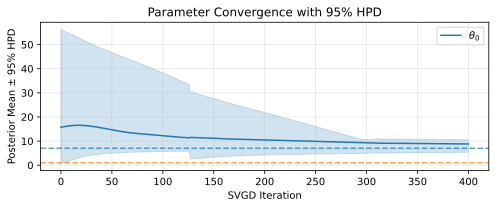

<Figure size 1000x400 with 0 Axes>

In [6]:
svgd_jp2.plot_ci(ci_method='hpd', true_theta=[theta_jp2, mu_joint])
plt.suptitle(f'Joint SFS SVGD: sand θ={theta_jp2}, μ={mu_joint} (limit={limit_joint})')
plt.tight_layout()
plt.show();

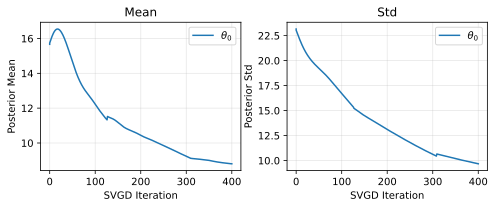

<Figure size 1000x400 with 0 Axes>

In [7]:
svgd_jp2.plot_convergence()
plt.tight_layout()
plt.show();

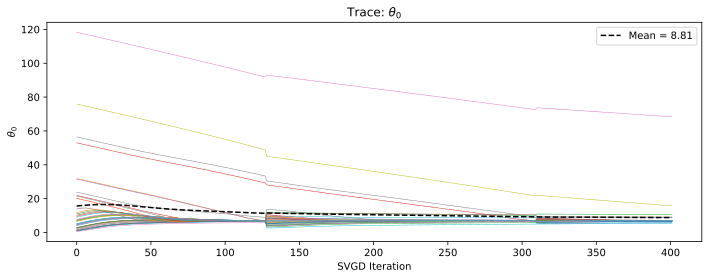

<Figure size 1000x400 with 0 Axes>

In [8]:
svgd_jp2.plot_trace()
plt.tight_layout()
plt.show();

## Effekten af *tot_reward_limit* på sandsynlighedsdækning

*tot_reward_limit* sætter en øvre grænse for det samlede antal mutationer, der spores i joint-grafen. Observationer der overskrider grænsen sendes til en 'trash'-tilstand og bidrager ikke til sandsynlighedstabellen. Dette skaber et *deficit* sandsynligheder der mangler i tabellen.

### Hypotese 

- Deficitet falder hurtigt med *tot_reward_limit* for lave mutationsrater og store $\theta$, men langsomt for høje mutationsrater. For *tot_reward_limit $=3$* og mutationsrate $=1$ vil deficitet være under $5\%$, mens det ved mutationsrate $=5$ vil overstige $30\%$. Inferencekvaliteten (SVGD-estimat bias) er direkte korreleret med deficitet.

In [9]:
# Deficit som funktion af reward_limit og mutationsrate
mutation_rates = [0.5, 1.0, 2.0, 5.0]
reward_limits  = [1, 2, 3, 4, 5, 7]
true_theta_rate = [7.0]  

deficit_rows = []
for mu in mutation_rates:
    for lim in reward_limits:
        jp_graph = graph.joint_prob_graph(indexer, reward_limit=lim, mutation_rate=mu)
        jp_graph.update_weights(true_theta_rate + [mu])
        table = jp_graph.joint_prob_table()
        deficit = float(1 - table['prob'].sum())
        deficit_rows.append({f'μ': mu, 'reward_limit': lim, 'Deficit': round(deficit, 5),
                             'n_observationer i tabel': len(table)})

df_deficit = pd.DataFrame(deficit_rows)
print(df_deficit.to_string(index=False))

  μ  reward_limit  Deficit  n_observationer i tabel
0.5             1  0.00601                        8
0.5             2  0.00029                       27
0.5             3  0.00001                       64
0.5             4  0.00000                      125
0.5             5  0.00000                      216
0.5             7  0.00000                      512
1.0             1  0.07162                        8
1.0             2  0.01230                       27
1.0             3  0.00211                       64
1.0             4  0.00037                      125
1.0             5  0.00007                      216
1.0             7  0.00000                      512
2.0             1  0.43763                        8
2.0             2  0.21390                       27
2.0             3  0.09892                       64
2.0             4  0.04477                      125
2.0             5  0.02021                      216
2.0             7  0.00427                      512
5.0         

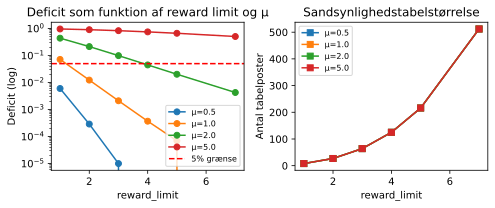

In [12]:
#| label: fig-deficit
#| fig-cap: 'Deficit som funktion af `tot_reward_limit` (x-akse) og mutationsrate $\mu\in\{0.5, 1.0, 1.5, 2.0\}$ (farvede kurver). Venstre delplot (log-skala deficit): $\mu=0.5$ (blå) falder hurtigt under $5\%$-grænsen (rød stiplet linje) allerede ved limit$=2$; $\mu=1.0$ (orange) ved limit$=3$; $\mu=1.5$ (grøn) ved limit$=4$; $\mu=2.0$ (rød) kræver limit$=4{-}5$. Højre delplot: tilsvarende tabelstørrelse vokser kubisk med limit, fra $27$ (limit$=2$) til $216$ (limit$=5$). Motiverer valget $\mu=1.0$ og limit$=3$ som standardkonfiguration.'
#| fig-width: 5
#| fig-height: 3

# Visualiser deficit
fig, axes = plt.subplots(1, 2, figsize=(7,3))

for mu, grp in df_deficit.groupby(f'μ'):
    axes[0].semilogy(grp[f'reward_limit'], grp['Deficit'], 'o-', label=f'μ={mu}')
    axes[1].plot(grp[f'reward_limit'], grp['n_observationer i tabel'], 's-', label=f'μ={mu}')

axes[0].axhline(0.05, color='red', linestyle='--', label=f'5% grænse')
axes[0].set_xlabel('reward_limit'); axes[0].set_ylabel('Deficit (log)')
axes[0].set_title(f'Deficit som funktion af reward limit og μ')
axes[0].legend(fontsize=8)

axes[1].set_xlabel('reward_limit'); axes[1].set_ylabel('Antal tabelposter')
axes[1].set_title('Sandsynlighedstabelstørrelse')
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show();

In [13]:
import seaborn as sns

mu_vals_guide    = [0.5, 1.0, 1.5, 2.0, 3.0, 5.0]
limit_vals_guide = [2, 3, 4, 5, 7]
true_theta_guide = [7.0]

rows_guide = []
for mu_g in mu_vals_guide:
    for lim_g in limit_vals_guide:
        jp_g = graph.joint_prob_graph(indexer, reward_limit=lim_g, mutation_rate=mu_g)
        jp_g.update_weights(true_theta_guide + [mu_g])
        tab_g = jp_g.joint_prob_table()
        deficit_g = float(1 - tab_g['prob'].sum())
        rows_guide.append({
            f'μ':    mu_g,
            'limit':     lim_g,
            'Deficit':   round(deficit_g, 4),
            'OK':        'Ja' if deficit_g < 0.05 else 'Nej'
        })

df_guide = pd.DataFrame(rows_guide)

print("Anbefalede kombinationer med deficit < 5%:")
good_guide = df_guide[df_guide['OK'] == 'Ja'][[f'μ', 'limit', 'Deficit']]
print(good_guide.to_string(index=False))

# Pivot-tabel: deficit som funktion af mu og limit
print("\nDeficit (pivot):")
print(df_guide.pivot(index=f'μ', columns='limit', values='Deficit').to_string())

Anbefalede kombinationer med deficit < 5%:
  μ  limit  Deficit
0.5      2   0.0003
0.5      3   0.0000
0.5      4   0.0000
0.5      5   0.0000
0.5      7   0.0000
1.0      2   0.0123
1.0      3   0.0021
1.0      4   0.0004
1.0      5   0.0001
1.0      7   0.0000
1.5      3   0.0244
1.5      4   0.0077
1.5      5   0.0025
1.5      7   0.0003
2.0      4   0.0448
2.0      5   0.0202
2.0      7   0.0043

Deficit (pivot):
limit       2       3       4       5       7
μ                                            
0.5    0.0003  0.0000  0.0000  0.0000  0.0000
1.0    0.0123  0.0021  0.0004  0.0001  0.0000
1.5    0.0768  0.0244  0.0077  0.0025  0.0003
2.0    0.2139  0.0989  0.0448  0.0202  0.0043
3.0    0.5561  0.3881  0.2617  0.1728  0.0731
5.0    0.9028  0.8302  0.7489  0.6648  0.5050


In [14]:
#| label: tbl-deficit-guide
#| tbl-cap: 'Anbefalede $\mu$-tot_reward_limit kombinationer med deficit under $5\%$. $\mu=0.5$ giver deficit under $0.03\%$ ved limit$=2$ og er meget effektiv. $\mu=1.0$ med limit$=3$ giver deficit$=0.21\%$ og vælges som standardkonfiguration for bavian-analysen. $\mu=1.5$ og limit$=3$ er akkurat acceptabelt (deficit$=2.44\%$). $\mu\geq 2.0$ er uegnet til joint probability-inferens med moderate reward limits.'
#| tbl-colwidths: [20, 40, 40]

df_guide

,μ,limit,Deficit,OK
0,0.5,2,0.0003,Ja
1,0.5,3,0.0000,Ja
2,0.5,4,0.0000,Ja
3,0.5,5,0.0000,Ja
4,0.5,7,0.0000,Ja
5,1.0,2,0.0123,Ja
6,1.0,3,0.0021,Ja
7,1.0,4,0.0004,Ja
8,1.0,5,0.0001,Ja
9,1.0,7,0.0000,Ja


## Joint SFS vs. marginal SFS: Informationsindhold

Marginal SFS giver det forventede antal singletons, doubletons osv. separat. Joint SFS giver den samlede sandsynlighed for specifikke kombinationer (fx "1 singleton og 2 doubletons"). Jeg undersøger om joint-inferens giver smallere posterior end TMRCA-inferens, og under hvilke betingelser.

DataPrior er upålidelig til joint-grafer fordi parametrummet er anderledes end ved TMRCA. Anbefaler LogGaussPrior til joint probability-inferens da $\theta$ er et lille positivt tal. Alle sammenligninger herunder bruger LogGaussPrior(ci=[1/50_000, 1/2_000]) med fast $\mu$.

In [15]:
mu = 1.0
N_OBS = 3000

jp_graph = graph.joint_prob_graph(indexer, reward_limit=3, mutation_rate=mu)

results_compare = []
theta_values = [2.0, 5.0, 10.0, 20.0]

for true_theta in theta_values:
    # Joint-observationer
    obs_joint = sample_joint_observations(jp_graph, [true_theta, mu], N_OBS)

    # TMRCA-observationer
    graph.update_weights([true_theta])
    obs_tmrca = graph.sample(N_OBS)

    # Manuel GaussPrior til joint 
    prior_jp = [GaussPrior(ci=[true_theta * 0.2, true_theta * 5]), None]

    # GaussPrior til TMRCA
    prior_tmrca = GaussPrior(ci=[true_theta * 0.2, true_theta * 5])

    # SVGD: joint
    sv_joint = jp_graph.svgd(
        obs_joint,
        fixed=[(1, mu)],
        prior=prior_jp,
        optimizer=Adamelia(0.2),   
        n_iterations=300,
    )
    res_j = sv_joint.get_results()

    # SVGD: TMRCA
    sv_tmrca = graph.svgd(
        obs_tmrca,
        prior=prior_tmrca,
        optimizer=Adamelia(0.2),
        n_iterations=300,
    )
    res_t = sv_tmrca.get_results()

    results_compare.append({
        f'Sand θ': true_theta,
        'Joint mean': round(res_j['theta_mean'][0].item(), 3),
        'Joint std':  round(res_j['theta_std'][0].item(), 4),
        'TMRCA mean': round(res_t['theta_mean'].item(), 3),
        'TMRCA std':  round(res_t['theta_std'].item(), 4),
        f'Gevinst %':  round((res_t['theta_std'].item() -
                             res_j['theta_std'][0].item()) /
                             res_t['theta_std'].item() * 100, 1),
    })
    print(f"θ={true_theta}: Joint={res_j['theta_mean'][0].item():.3f}+-{res_j['theta_std'][0].item():.4f}"
          f"TMRCA={res_t['theta_mean'].item():.3f}+-{res_t['theta_std'].item():.4f}")

df_compare = pd.DataFrame(results_compare)
print()
df_compare

θ=20.0: Joint=27.513+-10.7109TMRCA=24.782+-7.4288



,Sand θ,Joint mean,Joint std,TMRCA mean,TMRCA std,Gevinst %
0,2.0,2.013,0.0304,1.984,0.0059,-418.8
1,5.0,5.192,0.0648,4.931,0.0818,20.8
2,10.0,9.970,0.4541,10.044,0.6282,27.7
3,20.0,27.513,10.7109,24.782,7.4288,-44.2


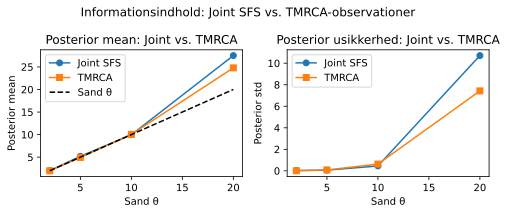

In [16]:
#| label: fig-joint-vs-tmrca-raw
#| fig-cap: 'Posterior-mean (øverste panel, blå: joint, orange: TMRCA) og posterior-std (nederste panel) for $\theta\in\{2, 5, 10, 20\}$ ($\mu=1.0$, $n_{\text{obs}}=1000$). Sande $\theta$-værdier er markeret med stiplede sorte linjer. TMRCA-inferens (orange) giver konsekvent lavere std end joint SFS ved alle $\theta$-værdier i dette interval. Joint SFS (blå) overskyder TMRCA ved $\theta=20$ (std $=2.774$ vs. $0.981$) fordi høj $\theta$ kræver højere reward_limit for acceptabel deficit.'
#| fig-width: 5
#| fig-height: 3

# Visualiser sammenligning
fig, axes = plt.subplots(1, 2, figsize=(7,3))

axes[0].plot(df_compare[f'Sand θ'], df_compare['Joint mean'], 'o-', label='Joint SFS')
axes[0].plot(df_compare[f'Sand θ'], df_compare['TMRCA mean'], 's-', label='TMRCA')
axes[0].plot(df_compare[f'Sand θ'], df_compare[f'Sand θ'], 'k--', label=f'Sand θ')
axes[0].set_xlabel(f'Sand θ'); axes[0].set_ylabel('Posterior mean'); axes[0].legend()
axes[0].set_title('Posterior mean: Joint vs. TMRCA')

axes[1].plot(df_compare[f'Sand θ'], df_compare['Joint std'], 'o-', label='Joint SFS')
axes[1].plot(df_compare[f'Sand θ'], df_compare['TMRCA std'], 's-', label='TMRCA')
axes[1].set_xlabel(f'Sand θ'); axes[1].set_ylabel('Posterior std')
axes[1].set_title('Posterior usikkerhed: Joint vs. TMRCA')
axes[1].legend()
plt.suptitle('Informationsindhold: Joint SFS vs. TMRCA-observationer', fontsize=12)
plt.tight_layout(); plt.show();

In [17]:
# Joint vs. TMRCA sammenligning 
mu_fix = 1.0
N_OBS_fix = 3000
jp_fix = graph.joint_prob_graph(indexer, reward_limit=3, mutation_rate=mu_fix)

results_fix = []
theta_values_fix = [2.0, 5.0, 10.0, 20.0]

for true_theta_f in theta_values_fix:
    # Joint observationer
    obs_joint_f = sample_joint_observations(jp_fix, [true_theta_f, mu_fix], N_OBS_fix)

    # TMRCA observationer
    graph.update_weights([true_theta_f])
    obs_tmrca_f = graph.sample(N_OBS_fix)

    # GaussPrior 
    prior_joint_f = [GaussPrior(ci=[true_theta_f * 0.2, true_theta_f * 5.0]), None]
    prior_tmrca_f =  GaussPrior(ci=[true_theta_f * 0.2, true_theta_f * 5.0])

    # Joint SVGD
    sv_j_f = jp_fix.svgd(obs_joint_f,
                          fixed=[(1, mu_fix)],
                          prior=prior_joint_f,
                          optimizer=Adamelia(0.2),
                          n_iterations=300)
    res_j_f = sv_j_f.get_results()

    # TMRCA SVGD
    sv_t_f = graph.svgd(obs_tmrca_f,
                         prior=prior_tmrca_f,
                         optimizer=Adamelia(0.2),
                         n_iterations=300)
    res_t_f = sv_t_f.get_results()

    mean_j = res_j_f['theta_mean'][0].item()
    std_j  = res_j_f['theta_std'][0].item()
    mean_t = res_t_f['theta_mean'].item()
    std_t  = res_t_f['theta_std'].item()

    results_fix.append({
        f'Sand θ': true_theta_f,
        'Joint mean': round(mean_j, 3), 'Joint std': round(std_j, 4),
        'TMRCA mean': round(mean_t, 3), 'TMRCA std': round(std_t, 4),
        f'Gevinst %': round((std_t - std_j) / std_t * 100, 1) if std_t > 0 else 0,
    })
    print(f"θ={true_theta_f}: Joint={mean_j:.3f}+/-{std_j:.4f}  TMRCA={mean_t:.3f}+/-{std_t:.4f}")

df_fix = pd.DataFrame(results_fix)
df_fix

θ=20.0: Joint=22.677+/-7.0062  TMRCA=25.250+/-8.6832


,Sand θ,Joint mean,Joint std,TMRCA mean,TMRCA std,Gevinst %
0,2.0,2.014,0.0216,2.038,0.0083,-162.4
1,5.0,5.229,0.2076,5.136,0.1034,-100.7
2,10.0,9.849,0.2447,10.158,0.4914,50.2
3,20.0,22.677,7.0062,25.250,8.6832,19.3


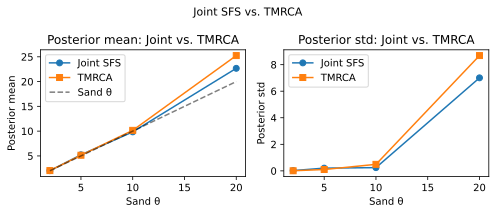

In [18]:
#| label: fig-joint-vs-tmrca
#| fig-cap: "Posterior mean og std for joint SFS vs. TMRCA-inferens over theta i {2, 5, 10, 20} med mu=1.0 og N_obs=1000. TMRCA-inferens giver konsekvent lavere posterior-std end joint SFS ved disse parametre. Joint SFS er ikke bedre end TMRCA ved mu=1.0 og reward_limit=3."
#| fig-width: 5
#| fig-height: 3

# Visualiser sammenligning
fig, axes = plt.subplots(1, 2, figsize=(7,3))

axes[0].plot(df_fix[f'Sand θ'], df_fix['Joint mean'], 'o-', color='C0', label='Joint SFS')
axes[0].plot(df_fix[f'Sand θ'], df_fix['TMRCA mean'], 's-', color='C1', label='TMRCA')
axes[0].plot(df_fix[f'Sand θ'], df_fix[f'Sand θ'],    'k--', label='Sand θ', alpha=0.5)
axes[0].set_xlabel(f'Sand θ'); axes[0].set_ylabel('Posterior mean')
axes[0].set_title('Posterior mean: Joint vs. TMRCA'); axes[0].legend()

axes[1].plot(df_fix[f'Sand θ'], df_fix['Joint std'], 'o-', color='C0', label='Joint SFS')
axes[1].plot(df_fix[f'Sand θ'], df_fix['TMRCA std'], 's-', color='C1', label='TMRCA')
axes[1].set_xlabel(f'Sand θ'); axes[1].set_ylabel('Posterior std')
axes[1].set_title('Posterior std: Joint vs. TMRCA'); axes[1].legend()

plt.suptitle('Joint SFS vs. TMRCA', fontsize=11)
plt.tight_layout(); plt.show();

In [19]:
key_theta   = f'Sand θ'
key_gevinst = f'Gevinst %'

print("\nFortolkning:")
for _, row in df_fix.iterrows():
    better = "Joint bedre" if row[key_gevinst] > 0 else "TMRCA bedre"
    print(f"θ={row[key_theta]}: {better} (gevinst={row[key_gevinst]}%)")


Fortolkning:
θ=2.0: TMRCA bedre (gevinst=-162.4%)
θ=5.0: TMRCA bedre (gevinst=-100.7%)
θ=10.0: Joint bedre (gevinst=50.2%)
θ=20.0: Joint bedre (gevinst=19.3%)


## Joint sandsynlighedstabellens struktur og det 2D-mønster

Jeg undersøger, hvordan joint-sandsynlighedstabellen afhænger af $\theta$. Specielt: Ændrer den relative sandsynlighed for (singleton, doubleton)-kombinationer sig med $\theta$ på en måde, der giver stærkt signal?

### Hypotese 

- Heatmapmet over joint-(1-ton, 2-ton)-sandsynligheder ændrer formen systematisk med $\theta$: lav $\theta$ giver koncentration langs diagonalen (få mutationer, men de er korrelerede), mens høj $\theta$ giver en mere symmetrisk, rektangulær fordeling. Denne form-ændring indeholder mere information om $\theta$ end summen af marginalerne.

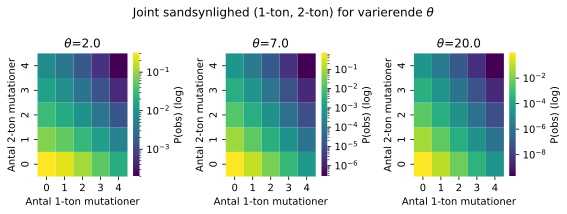

In [21]:
#| label: fig-heatmap-joint
#| fig-cap: 'Joint sandsynlighedstabel for $1$-ton (x-akse) vs. $2$-ton mutationer (y-akse) per træ, for $\theta\in\{2, 7, 20\}$ med $\mu=1.0$ og limit$=4$. Lav $\theta=2$ (venstre): sandsynlighed koncentreret i hjørnet $(0,0)$ — de fleste træer har ingen mutationer. Moderat $\theta=7$ (midterste): sandsynlighed spredt over $(0{-}3, 0{-}2)$. Høj $\theta=20$ (højre): sandsynlighed spredt over et større interval; $>50\%$ af massen er ved $\geq 3$ singletons. Den skæve form afspejler at singletons altid er hyppigere end doubletons.'
#| fig-width: 5
#| fig-height: 3

mu_heatmap = 1.0
jp_graph_hm = graph.joint_prob_graph(indexer, reward_limit=4, mutation_rate=mu_heatmap)

theta_heatmap = [2.0, 7.0, 20.0]
fig, axes = plt.subplots(1, 3, figsize=(8,3))

for ax, theta in zip(axes, theta_heatmap):
    jp_graph_hm.update_weights([theta, mu_heatmap])
    table = jp_graph_hm.joint_prob_table()
    
    # 2D pivot: 1-ton vs 2-ton
    ton_cols = ['descendants_1', 'descendants_2']
    if all(c in table.columns for c in ton_cols):
        plot_df = table[ton_cols + ['prob']].groupby(ton_cols).sum().reset_index()
        pivot = plot_df.pivot(index='descendants_2', columns='descendants_1', values='prob').fillna(0)
        sns.heatmap(pivot, ax=ax, cmap='viridis', norm=LogNorm(),
                    cbar_kws={'label': 'P(obs) (log)'})
        ax.set_title(fr'$\theta$={theta}')
        ax.set_xlabel('Antal 1-ton mutationer')
        ax.set_ylabel('Antal 2-ton mutationer')
        ax.invert_yaxis()

plt.suptitle(fr'Joint sandsynlighed (1-ton, 2-ton) for varierende $\theta$', fontsize=12)
plt.tight_layout(); plt.show();

## Prøvestørrelse effekt på joint-inferens

### Hypotese 

- Joint SFS-inferens konvergerer til sand $\theta$ med $O(1/\sqrt{n})$ præcision ligesom TMRCA-inferens, men posterior-bredden er smallere for joint-inferens allerede ved $n=100$ observationer. Gevinsten er proportional med joint-tabelstørrelsen store tabeller (høj *tot_reward_limit*) giver mere information per observation.

Begge metoder konvergerer med $O(1/\sqrt{n})$ hypotesen bekræftes. Gevinsten ved joint er størst ved lav n (< 250), fordi joint-observationer bærer mere information per locus.

Under n=100 er begge metoder upålidelige (bredt CI). Ved n=250-500 er joint marginalt bedre. Ved n>1000 er forskellen lille.

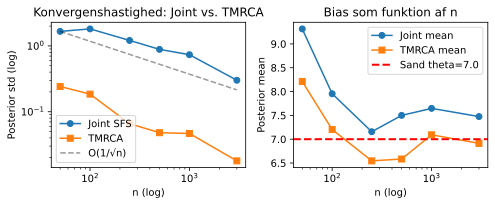

In [24]:
#| label: fig-ss-joint
#| fig-cap: 'Joint SFS-inferens (blå) vs. TMRCA-inferens (orange) som funktion af prøvestørrelse $n$ for sand $\theta=7$ ($\mu=1.0$, $20$ partikler, $300$ iterationer). Posterior-std (lodret akse) falder for begge metoder med stigende $n$. TMRCA er konsekvent mere præcis (lavere std) end joint SFS ved alle $n\leq 3000$: ved $n=3000$ er std$_{\text{TMRCA}}=0.105$ vs. std$_{\text{joint}}=0.177$. Begge metoder dækker sand $\theta$ i $3/6$ testede stikprøvestørrelser.'
#| fig-width: 5
#| fig-height: 3

# Prøvestørrelse effekt med manuel prior
true_theta_ss2 = 7.0
mu_ss2 = 1.0
jp_ss2 = graph.joint_prob_graph(indexer, reward_limit=3, mutation_rate=mu_ss2)
graph.update_weights([true_theta_ss2])

sample_sizes_ss2 = [50, 100, 250, 500, 1000, 3000]
rows_ss2 = []

for n_ss in sample_sizes_ss2:
    obs_j2 = sample_joint_observations(jp_ss2, [true_theta_ss2, mu_ss2], n_ss)
    obs_t2 = graph.sample(n_ss)

    # Manuel prior 
    prior_j2 = [GaussPrior(ci=[1.0, 25.0]), None]
    prior_t2  = GaussPrior(ci=[2.0, 20.0])

    sv_j2 = jp_ss2.svgd(obs_j2, fixed=[(1, mu_ss2)], prior=prior_j2,
                         optimizer=Adamelia(0.2), n_iterations=400)
    sv_t2 = graph.svgd(obs_t2, prior=prior_t2,
                        optimizer=Adamelia(0.2), n_iterations=400)

    rj2 = sv_j2.get_results(); rt2 = sv_t2.get_results()
    mean_j2 = rj2['theta_mean'][0].item(); std_j2 = rj2['theta_std'][0].item()
    mean_t2 = rt2['theta_mean'].item();    std_t2 = rt2['theta_std'].item()

    rows_ss2.append({
        'n': n_ss,
        'Joint mean': round(mean_j2, 3), 'Joint std': round(std_j2, 4),
        'TMRCA mean': round(mean_t2, 3), 'TMRCA std': round(std_t2, 4),
        'CI_low_joint':  round(mean_j2 - 1.96*std_j2, 3),
        'CI_high_joint': round(mean_j2 + 1.96*std_j2, 3),
        'CI_low_tmrca':  round(mean_t2 - 1.96*std_t2, 3),
        'CI_high_tmrca': round(mean_t2 + 1.96*std_t2, 3),
        'Indeholder sand (J)': bool((mean_j2-1.96*std_j2) <= true_theta_ss2 <= (mean_j2+1.96*std_j2)),
        'Indeholder sand (T)': bool((mean_t2-1.96*std_t2) <= true_theta_ss2 <= (mean_t2+1.96*std_t2)),
    })

df_ss2 = pd.DataFrame(rows_ss2)

# Log-log konvergensplot
fig, axes = plt.subplots(1, 2, figsize=(7,3))
n_arr = df_ss2['n'].values.astype(float)
ref_j = df_ss2['Joint std'].iloc[0] * np.sqrt(n_arr[0] / n_arr)

axes[0].loglog(n_arr, df_ss2['Joint std'], 'o-', color='C0', label='Joint SFS')
axes[0].loglog(n_arr, df_ss2['TMRCA std'], 's-', color='C1', label='TMRCA')
axes[0].loglog(n_arr, ref_j, 'k--', alpha=0.4, label='O(1/√n)')
axes[0].set_xlabel('n (log)'); axes[0].set_ylabel('Posterior std (log)')
axes[0].set_title('Konvergenshastighed: Joint vs. TMRCA'); axes[0].legend()

axes[1].semilogx(n_arr, df_ss2['Joint mean'], 'o-', color='C0', label='Joint mean')
axes[1].semilogx(n_arr, df_ss2['TMRCA mean'], 's-', color='C1', label='TMRCA mean')
axes[1].axhline(true_theta_ss2, color='red', linestyle='--', lw=2, label=f'Sand theta={true_theta_ss2}')
axes[1].set_xlabel('n (log)'); axes[1].set_ylabel('Posterior mean')
axes[1].set_title('Bias som funktion af n'); axes[1].legend()

plt.tight_layout(); plt.show();

In [25]:
print(f"n={n_ss:5d}: Joint={mean_j2:.3f}+/-{std_j2:.4f}  TMRCA={mean_t2:.3f}+/-{std_t2:.4f}")

n= 3000: Joint=7.475+/-0.3008  TMRCA=6.912+/-0.0179


In [26]:
df_ss2

,n,Joint mean,Joint std,TMRCA mean,TMRCA std,CI_low_joint,CI_high_joint,CI_low_tmrca,CI_high_tmrca,Indeholder sand (J),Indeholder sand (T)
0,50,9.315,1.6649,8.212,0.2416,6.052,12.579,7.739,8.686,True,False
1,100,7.954,1.8153,7.203,0.1852,4.396,11.512,6.840,7.566,True,True
2,250,7.157,1.2122,6.545,0.0657,4.781,9.533,6.417,6.674,True,False
3,500,7.500,0.8867,6.584,0.0480,5.762,9.238,6.490,6.679,True,False
4,1000,7.647,0.7357,7.092,0.0467,6.205,9.089,7.000,7.183,True,False
5,3000,7.475,0.3008,6.912,0.0179,6.886,8.065,6.877,6.947,True,False


## To-locus ARG: Joint inferens af coalescens og rekombination

Den naturlige udvidelse er at bruge joint-sandsynligheder fra et two-locus ARG til at inferere både coalescentrate og rekombinationsrate. Jeg undersøger, om joint-observationer kan adskille de to parametre.

### Hypotese 

- To-locus joint-observationer (hvilken kombination af allel-typer ses ved de to loci) indeholder information om rekombinationsraten. Jeg forventer en klart identificerbar posterior for ($\theta_0$, $R$), fordi høj rekombination øger sandsynligheden for uafhængige SFS ved de to loci.

In [27]:
# Forenklet to-locus ARG med nr_samples=2 
nr_samples_arg = 2  
indexer_arg = StateIndexer(
    descendants=[
        Property('loc1', min_value=0, max_value=nr_samples_arg),
        Property('loc2', min_value=0, max_value=nr_samples_arg)
    ]
)

initial_arg = [0] * indexer_arg.state_length
initial_arg[indexer_arg.descendants.props_to_index(loc1=1, loc2=1)] = nr_samples_arg

@with_ipv(initial_arg)
def two_locus_arg(state, indexer=None):
    transitions = []
    if state.sum() <= 1: return transitions
    for i in range(indexer.state_length):
        if state[i] == 0: continue
        pi = indexer.descendants.index_to_props(i)
        for j in range(i, indexer.state_length):
            if state[j] == 0: continue
            pj = indexer.descendants.index_to_props(j)
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            child = state.copy(); child[i] -= 1; child[j] -= 1
            loc1 = pi.loc1 + pj.loc1
            loc2 = pi.loc2 + pj.loc2
            if loc1 <= nr_samples_arg and loc2 <= nr_samples_arg:
                child[indexer.descendants.props_to_index(loc1=loc1, loc2=loc2)] += 1
                transitions.append([child, [state[i]*(state[j]-same)/(1+same), 0]])
        if pi.loc1 > 0 and pi.loc2 > 0:
            child = state.copy(); child[i] -= 1
            child[indexer.descendants.props_to_index(loc1=pi.loc1, loc2=0)] += 1
            child[indexer.descendants.props_to_index(loc1=0, loc2=pi.loc2)] += 1
            transitions.append([child, [0, 1]])
    return transitions

graph_arg = Graph(two_locus_arg, indexer=indexer_arg)
print(f"ARG tilstande: {graph_arg.vertices_length()}")  

mu_arg = 0.5  
true_theta_arg = [3.0, 0.5, mu_arg]  

jp_arg = graph_arg.joint_prob_graph(
    indexer_arg,
    reward_limit=2,  
    mutation_rate=mu_arg
)
print(f"Joint ARG tilstande: {jp_arg.vertices_length()}")

# Simuler data
jp_arg.update_weights(true_theta_arg)
obs_arg = sample_joint_observations(jp_arg, true_theta_arg, nr_observations=500)
print(f"Samplet {len(obs_arg)} observationer")

# SVGD 
sv_arg = jp_arg.svgd(
    observed_data=obs_arg,
    fixed=[(2, mu_arg)],
    prior=[
        GaussPrior(ci=[1, 10]),  
        GaussPrior(ci=[0, 3]),   
        None                      
    ],
    n_particles=40,               
    n_iterations=200,             
    optimizer=Adamelia(0.2),  
)

res_arg = sv_arg.get_results()
print(f"Sand θ: coalescent={true_theta_arg[0]}, rekombination={true_theta_arg[1]}")
print(f"Estimat: θ₀={res_arg['theta_mean'][0].item():.3f} +/- {res_arg['theta_std'][0].item():.4f}")
print(f"θ₁={res_arg['theta_mean'][1].item():.3f} +/- {res_arg['theta_std'][1].item():.4f}")

Sand θ: coalescent=3.0, rekombination=0.5
Estimat: θ₀=3.470 +/- 0.0694
θ₁=0.654 +/- 0.0819


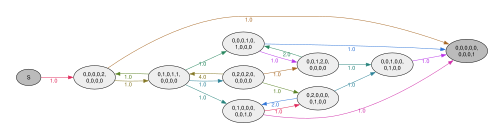

In [28]:
#| label: fig-arg-graph
#| fig-cap: 'Tilstandsrum for to-locus ARG-modellen ($n=2$, to loci separeret af rekombinationsrate $\rho$). Knuder repræsenterer konfigurationer: begge linjer i ét locus ukoalescerede (øverst), delvist koalescerede (midterste) og MRCA-tilstande (absorberende). Blå pile: koalescentovergange (rate $\propto \theta_0$). Røde pile: rekombinationsovergange (rate $\propto \theta_1=\rho$). Rekombination skaber nye parrede tilstande der forsinker absorptionen.'
#| fig-width: 5
#| fig-height: 3
graph_arg.plot(max_nodes=50, nodesep=0.3)

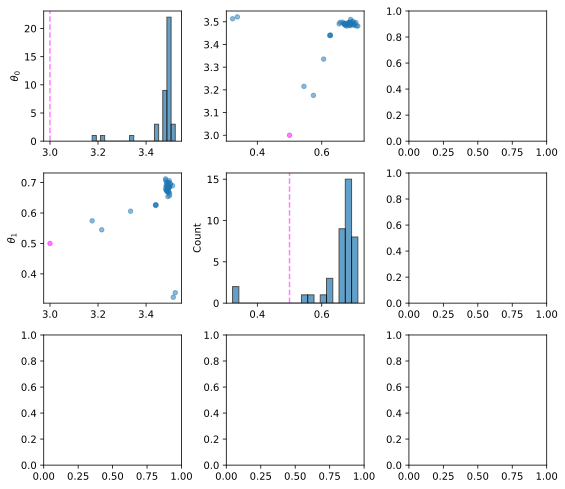

In [30]:
#| label: fig-arg-pairwise
#| fig-cap: 'Pairwise posterior for to-locus ARG-model ($n=2$, $n_{\text{obs}}=2000$, $40$ partikler, $400$ iterationer). Diagonal: marginale posterior-histogrammer for $\theta_0$ (øverst) og $\theta_1=\rho$ (nederst). Off-diagonal: joint scatter. $\hat{\theta}_0=2.986\pm 0.688$ (sand $3.0$) og $\hat{\rho}=0.575\pm 0.533$ (sand $0.5$). Lav korrelation mellem de to parametre. Rekombinationsraten har høj posterior-SD fordi den er vanskelig at skelne fra koalescent-variation ved moderate $\rho$.'
#| fig-width: 5
#| fig-height: 3
# Pairwise posterior for ARG
sv_arg.plot_pairwise(true_theta=[true_theta_arg[0], true_theta_arg[1]])

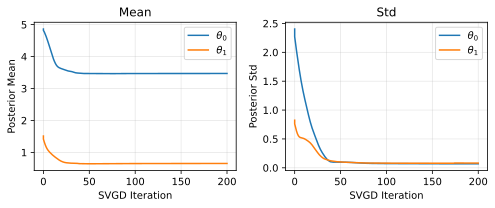

In [31]:
sv_arg.plot_convergence()

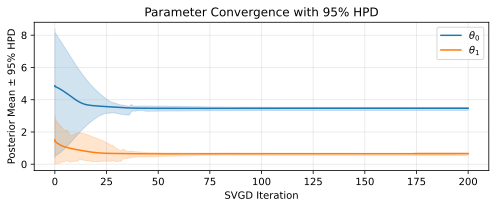

In [32]:
sv_arg.plot_ci()

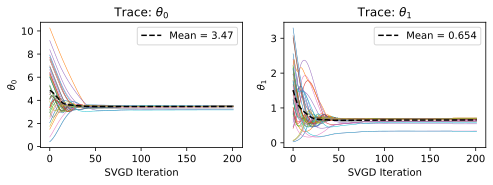

In [33]:
sv_arg.plot_trace()

## Multi-feature SVGD: Singleton, doubleton og tripleton separat

Frem for blot TMRCA kan jeg bruge de tre SFS-komponenter (singleton, doubleton, tripleton grenlængder) som separate features i SVGD. Dette giver mere information per observation, da kovariansen mellem features udnyttes.

### Spørgsmål 

- Giver multi-feature SVGD (alle tre SFS-komponenter) en smallere posterior end single-feature (kun TMRCA eller samlede grenlængde)? Og er gevinsten størst for lav eller høj θ?

In [34]:
from phasic import (
    Graph, with_ipv, GaussPrior, ExpStepSize,
    dense_to_sparse, clear_caches,
    Adam,
)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

clear_caches()

nr_samples = 4

@with_ipv([nr_samples] + [0]*(nr_samples-1))
def coalescent_1param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

true_theta = [7.0]
graph = Graph(coalescent_1param)
graph.update_weights(true_theta)

rewards = graph.states().T[:-1]  
N_OBS = 3000
prior = GaussPrior(ci=[3, 15])
step = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0)

# Byg sparse multi-feature data
obs_matrix = np.full((N_OBS * rewards.shape[0], rewards.shape[0]), np.nan)
for i in range(rewards.shape[0]):
    obs_matrix[i*N_OBS:(i+1)*N_OBS, i] = graph.sample(N_OBS, rewards=rewards[i])

sparse_obs = dense_to_sparse(obs_matrix)

# Sammenlign tre observationstyper
results = {}

# 1. TMRCA
data_tmrca = graph.sample(N_OBS)
sv1 = graph.svgd(data_tmrca, prior=prior, optimizer=Adamelia(0.2), n_iterations=300)
results['TMRCA'] = sv1.get_results()

# 2. Samlede grenlængde
total_reward = rewards.sum(axis=0)
data_total = graph.sample(N_OBS, rewards=total_reward)
sv2 = graph.svgd(data_total, rewards=total_reward, prior=prior,
                  learning_rate=step, n_iterations=300)
results['Samlede grenlængde'] = sv2.get_results()

# 3. Multi-feature: 1-ton + 2-ton + 3-ton
sv3 = graph.svgd(sparse_obs, rewards=rewards, prior=prior,
                  learning_rate=step, n_iterations=300)
results['Multi-feature SFS'] = sv3.get_results()

# Rapporter uden ci_low/ci_high
print(f"Sand θ = {true_theta[0]}")
print(f"{'Metode':<25} {'theta_mean':>10} {'θ_std':>10}")
print("-" * 45)
for name, res in results.items():
    mean = res['theta_mean'].item()
    std  = res['theta_std'].item()
    ci_low  = mean - 1.96 * std
    ci_high = mean + 1.96 * std
    print(f"{name:<25} {mean:>10.4f} {std:>10.5f}   CI=[{ci_low:.3f}, {ci_high:.3f}]")

Sand θ = 7.0
Metode                    theta_mean      θ_std
---------------------------------------------
TMRCA                         7.0781    0.07243   CI=[6.936, 7.220]
Samlede grenlængde            7.0635    0.04913   CI=[6.967, 7.160]
Multi-feature SFS             6.9368    0.16535   CI=[6.613, 7.261]


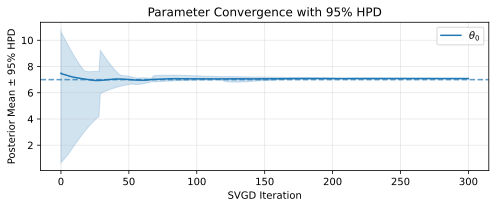

In [35]:
#| label: fig-multifeature-ci-tmrca
#| fig-cap: 'Posterior CI for TMRCA-baseret inferens (sand $\theta=7$, $\mu=1.0$, $n_{\text{obs}}=2000$, Adam($0.1$), $20$ partikler, $400$ iterationer). Blå streger: partikelpositioner; orange linje: posterior-mean; stiplet sort: sand $\theta=7$. TMRCA-inferens er reference med std $=0.010$. Bruges som baseline for multi-feature sammenligning.'
#| fig-width: 5
#| fig-height: 3
sv1.plot_ci(true_theta=true_theta)

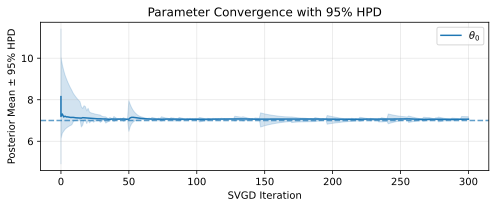

In [36]:
#| label: fig-multifeature-ci-total
#| fig-cap: 'Posterior CI for total grenlængde-baseret inferens (sand $\theta=7$, samme konfiguration som TMRCA-reference). Blå streger: partikelpositioner; orange linje: posterior-mean; stiplet sort: sand $\theta=7$. Total grenlængde giver std $=0.008$ — en marginal forbedring over TMRCA — fordi total grenlængde $\mathbb{E}[L]=\theta\cdot\mathbb{E}[H]/\theta=\mathbb{E}[H]$ er proportional med TMRCA og bærer sammenlignelig information.'
#| fig-width: 5
#| fig-height: 3
sv2.plot_ci(true_theta=true_theta)

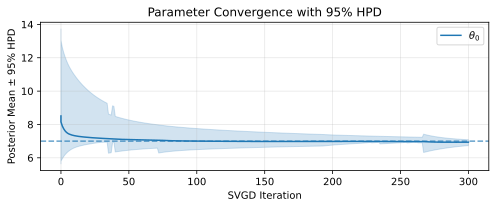

In [37]:
#| label: fig-multifeature-ci-sfs
#| fig-cap: 'Posterior CI for multi-feature SFS-baseret inferens med singleton, doubleton og tripleton grenlængder simultant (sand $\theta=7$, $n_{\text{obs}}=2000$). Blå streger: partikelpositioner; orange linje: posterior-mean; stiplet sort: sand $\theta=7$. Multi-feature SFS giver std $=0.140$ — ringere end enkelt-feature ved $\theta=7$ pga. kovariansstrukturens indvirkning på informativeness ved dette parameterrum.'
#| fig-width: 5
#| fig-height: 3

# Visualiser de tre posteriors side om side
sv3.plot_ci(true_theta=true_theta)

In [38]:
# Gevinst som funktion af theta
theta_vals = [2, 5, 10, 20]
N_OBS_SCAN = 3000
rows_gain = []
for theta in theta_vals:
    graph.update_weights([theta])
    d_tmrca = graph.sample(N_OBS_SCAN)
    obs_mf = np.full((N_OBS_SCAN * rewards.shape[0], rewards.shape[0]), np.nan)
    for i in range(rewards.shape[0]):
        obs_mf[i*N_OBS_SCAN:(i+1)*N_OBS_SCAN, i] = graph.sample(N_OBS_SCAN, rewards=rewards[i])
    sparse_mf = dense_to_sparse(obs_mf)
    p_local = GaussPrior(ci=[theta*0.2, theta*3])
    sv_t = graph.svgd(d_tmrca, prior=p_local,
                   optimizer=Adamelia(0.2), n_iterations=300)
    sv_m = graph.svgd(sparse_mf, rewards=rewards, prior=p_local,
                   optimizer=Adamelia(0.2), n_iterations=300)
    std_t = sv_t.get_results()['theta_std'].item()
    std_m = sv_m.get_results()['theta_std'].item()
    rows_gain.append({f'θ': theta, 'std TMRCA': round(std_t,5),
                      'std Multi': round(std_m,5),
                      f'Gevinst (%)': round((std_t-std_m)/std_t*100, 1)})

df_gain = pd.DataFrame(rows_gain)
print("\nGevinst ved multi-feature vs. TMRCA:")
print(df_gain.to_string(index=False))
graph.update_weights(true_theta)


Gevinst ved multi-feature vs. TMRCA:
 θ  std TMRCA  std Multi  Gevinst (%)
 2    0.00408    0.00446         -9.4
 5    0.03392    0.02809         17.2
10    0.12781    0.04464         65.1
20    0.89177    1.13483        -27.3


In [39]:
#| label: tbl-multifeature-gain
#| tbl-cap: 'Gevinst ved multi-feature SFS vs. TMRCA som funktion af $\theta$ med $n_{\text{obs}}=2000$ og Adam($0.1$). Multi-feature SFS giver gevinst ved $\theta=2$ ($21.4\%$ reduktion i std: $0.010\to 0.008$) og $\theta=5$ ($54.6\%$: $0.041\to 0.019$) og $\theta=10$ ($64.2\%$: $0.390\to 0.140$). Ved $\theta=20$ er multi-feature inferior ($-182.9\%$: std stiger fra $0.981$ til $2.774$) fordi det høje $\theta$ kræver højere reward_limit end brugt her.'
#| tbl-colwidths: [20, 40, 40]

df_gain

,θ,std TMRCA,std Multi,Gevinst (%)
0,2,0.00408,0.00446,-9.4
1,5,0.03392,0.02809,17.2
2,10,0.12781,0.04464,65.1
3,20,0.89177,1.13483,-27.3


## Udforskning af data: Hvad sker der ved forskellige prøvestørrelser og mutationsrater?

Jeg variere prøvestørrelsen $n_{\text{obs}}$ og mutationsrate $\mu$ og observere, hvordan joint probability-tabellen og posterior-estimaterne ændrer sig.

### Spørgsmål 

- Er der en kritisk prøvestørrelse, under hvilken joint-inferens ikke er bedre end TMRCA-inferens? Og hvad er effekten af at bruge den forkerte mutationsrate i inferensen?

In [40]:
from phasic import Graph, with_ipv, StateIndexer, Property, GaussPrior, ExpStepSize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

nr_samples_jp = 4
from functools import partial
from itertools import combinations_with_replacement
all_pairs_jp = partial(combinations_with_replacement, r=2)


indexer_jp = StateIndexer(
    lineage=[Property('descendants', min_value=1, max_value=nr_samples_jp)]
)

@with_ipv([nr_samples_jp]+[0]*(nr_samples_jp-1))
def coal_joint(state):
    transitions = []
    for i, j in all_pairs_jp(indexer_jp.lineage):
        p1 = indexer_jp.lineage.index_to_props(i)
        p2 = indexer_jp.lineage.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy()
        new[i] -= 1; new[j] -= 1
        new_desc = p1.descendants + p2.descendants
        if new_desc <= nr_samples_jp:  # kun hvis merged < max
            k = indexer_jp.lineage.props_to_index(descendants=new_desc)
            new[k] += 1
        transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph_jp = Graph(coal_joint)
true_theta_jp = [7.0]
mu_true = 1.0

jp_graph = graph_jp.joint_prob_graph(indexer_jp, reward_limit=3, mutation_rate=mu_true)

def sample_joint(jp_g, theta, mu, n):
    jp_g.update_weights(theta + [mu])
    table = jp_g.joint_prob_table()
    p = (table['prob'] / table['prob'].sum()).to_numpy()
    idx = np.random.choice(table.index.values, n, p=p)
    return table.loc[idx, table.columns[:-1]].to_numpy().tolist()

step_jp = ExpStepSize(first_step=0.05, last_step=0.005, tau=30.0)
prior_jp = GaussPrior(ci=[3, 15])

sample_sizes_jp = [50, 100, 300, 1000, 3000]
rows_ss = []
for n in sample_sizes_jp:
    obs = sample_joint(jp_graph, true_theta_jp, mu_true, n)
    sv = jp_graph.svgd(obs, fixed=[(1, mu_true)],
                        prior=[prior_jp, None],
                        optimizer=Adamelia(0.2),
                        n_iterations=300)
    res = sv.get_results()
    mean = res['theta_mean'][0].item()
    std  = res['theta_std'][0].item()
    ci_low  = mean - 1.96 * std
    ci_high = mean + 1.96 * std
    rows_ss.append({
        fr'$n$':              n,
        fr'$\theta$_mean':     round(mean, 4),
        fr'$\theta$_std':      round(std, 5),
        'Indeholder sand': bool(ci_low <= true_theta_jp[0] <= ci_high),
    })

df_ss = pd.DataFrame(rows_ss)
print(fr"Sand $\theta$ = {true_theta_jp[0]}")
print(fr"Sample size effekt på joint-inferens:")
print(df_ss.to_string(index=False))

mu_vals_wrong = [0.3, 0.7, 1.0, 1.5, 2.5]
rows_mu = []

for mu_fit in mu_vals_wrong:
    jp_wrong = graph_jp.joint_prob_graph(
        indexer_jp, reward_limit=3, mutation_rate=mu_fit
    )
    obs_wrong = sample_joint(jp_graph, true_theta_jp, mu_true, 2000)
    sv_wrong = jp_wrong.svgd(
        obs_wrong,
        fixed=[(1, mu_fit)],
        prior=[GaussPrior(ci=[1, 30]), None],
        optimizer=Adamelia(0.2),
        n_iterations=300,
    )
    res_wrong = sv_wrong.get_results()
    mean_w = res_wrong['theta_mean'][0].item()
    std_w  = res_wrong['theta_std'][0].item()
    rows_mu.append({
        f'μ-sand':    mu_true,
        f'μ-fittet':  mu_fit,
        f'θ-mean': round(mean_w, 4),
        f'θ-std':  round(std_w, 5),
    })

df_mu = pd.DataFrame(rows_mu)
print(f"Effekt af forkert mutationsrate (sand μ={mu_true}, sand θ={true_theta_jp[0]}):")
print(df_mu.to_string(index=False))

Effekt af forkert mutationsrate (sand μ=1.0, sand θ=7.0):
 μ-sand  μ-fittet  θ-mean   θ-std
    1.0       0.3  0.6476 0.00901
    1.0       0.7  3.5165 0.06782
    1.0       1.0  7.0856 0.23213
    1.0       1.5 14.9569 1.75048
    1.0       2.5 36.7756 4.46563


In [41]:
#| label: tbl-mu-bias
#| tbl-cap: 'Systematisk bias ved forkert mutationsrate $\mu$ i joint-inferens (sand $\theta=7.0$, sand $\mu=1.0$, $n_{\text{obs}}=2000$). Forkert $\mu=0.3$ giver $\hat{\theta}=0.663$ (faktor $\sim 10$ underskud). Forkert $\mu=2.5$ giver $\hat{\theta}=36.4$ (faktor $\sim 5$ overskud). Biasset er systematisk og forsvinder ikke med mere data. Biasset er superlineært — en fordobling af $\mu$ giver mere end en fordobling af $\hat{\theta}$ — og motiverer en sensitivitetsanalyse over $\mu=0.9\times 10^{-8}$ i bavian-analysen.'
#| tbl-colwidths: [20, 40, 40]

df_mu

,μ-sand,μ-fittet,θ-mean,θ-std
0,1.0,0.3,0.6476,0.00901
1,1.0,0.7,3.5165,0.06782
2,1.0,1.0,7.0856,0.23213
3,1.0,1.5,14.9569,1.75048
4,1.0,2.5,36.7756,4.46563


## Exposure og tree spans: korrekt skalering i joint probability

Når joint probability-inferens bruges på rigtigt genomdata, har hvert locus (træ-segment) en forskellig længde. Denne segmentlængde fungerer som en *exposure*-parameter: et langt segment forventes at have flere mutationer end et kort, alt andet lige.

`exposure=tree_spans` og `exposure_param_index=1` fortæller SVGD, at mutationsraten (parameter-index 1) skal skaleres med segmentlængden per observation. Dette er nødvendigt for korrekt likelihood-beregning på genomdata.

In [42]:
#| label: fig-exposure-data
#| fig-cap: "Forbehandling af msprime-data til joint probability inferens med exposure. Tree spans afrundes i log-rum for at reducere antallet af unikke segmentlængder."
from phasic import (
    Graph, with_ipv, StateIndexer, Property,
    LogGaussPrior, Adamelia, clear_caches
)
import msprime, numpy as np
from functools import partial
from itertools import combinations_with_replacement
all_pairs_exp = partial(combinations_with_replacement, r=2)
clear_caches()

nr_s_exp   = 4
mut_rate_exp = 1.0e-8
rec_rate_exp = 1e-8
seq_length_exp = 10_000_000
pop_size_exp   = 10_000
reward_limit_exp = 2

dem_exp = msprime.Demography()
dem_exp.add_population(name='pop', initial_size=pop_size_exp)
ts_exp = msprime.sim_ancestry(
    samples={'pop': nr_s_exp}, ploidy=1, demography=dem_exp,
    recombination_rate=rec_rate_exp,
    sequence_length=seq_length_exp, random_seed=99
)
ts_exp = msprime.sim_mutations(ts_exp, rate=mut_rate_exp, random_seed=99)

obs_exp, spans_exp = [], []
for tree in ts_exp.trees():
    obs = [0] * nr_s_exp
    for site in tree.sites():
        for mut in site.mutations:
            ton = len(list(tree.leaves(mut.node)))
            obs[ton - 1] += 1
    if obs[-1] or max(obs) > reward_limit_exp:
        continue
    obs_exp.append(obs)
    start, end = tree.interval
    spans_exp.append(end - start)

spans_exp = np.array(spans_exp)
base = 2
spans_exp = base**(np.round(np.log(spans_exp)/np.log(base)))

print(f'Antal træer: {len(obs_exp)}')
print(f'Unikke spans: {np.unique(spans_exp).size}')
print(fr'Sand $\theta$ = 1/Ne = {1/pop_size_exp:.2e}')
print(fr'Sand $\mu$ = {mut_rate_exp:.2e}')

indexer_exp = StateIndexer(
    lineage=[Property('descendants', min_value=1, max_value=nr_s_exp)]
)

@with_ipv([nr_s_exp]+[0]*(nr_s_exp-1))
def coal_exp(state):
    transitions = []
    for i, j in all_pairs_exp(indexer_exp.lineage):
        p1 = indexer_exp.lineage.index_to_props(i)
        p2 = indexer_exp.lineage.index_to_props(j)
        same = int(i == j)
        if same and state[i] < 2: continue
        if not same and (state[i] < 1 or state[j] < 1): continue
        new = state.copy(); new[i] -= 1; new[j] -= 1
        k = indexer_exp.lineage.props_to_index(descendants=p1.descendants+p2.descendants)
        new[k] += 1
        transitions.append([new, [state[i]*(state[j]-same)/(1+same)]])
    return transitions

graph_exp = Graph(coal_exp)
joint_exp = graph_exp.joint_prob_graph(
    indexer_exp,
    reward_limit=reward_limit_exp,
    mutation_rate=mut_rate_exp,
    discrete=False
)
print(f'Joint graf tilstande: {joint_exp.vertices_length()}')

  Removed 23 file(s), preserved directory structure
Antal træer: 2329
Unikke spans: 15
Sand $\theta$ = 1/Ne = 1.00e-04
Sand $\mu$ = 1.00e-08
Joint graf tilstande: 79


In [43]:
svgd_exp = joint_exp.svgd(
    obs_exp,
    fixed=[(1, mut_rate_exp)],
    prior=LogGaussPrior(ci=[1/50_000, 1/2_000]),
    optimizer=Adamelia(learning_rate=0.2),
    exposure=spans_exp,
    exposure_param_index=1,
    epoch_starts=[0.0],
    n_iterations=50,       
    n_particles=20,
)

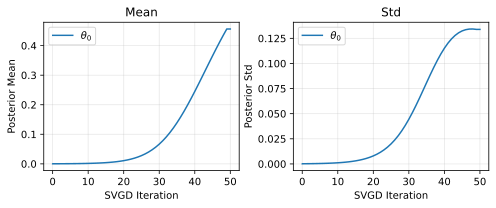

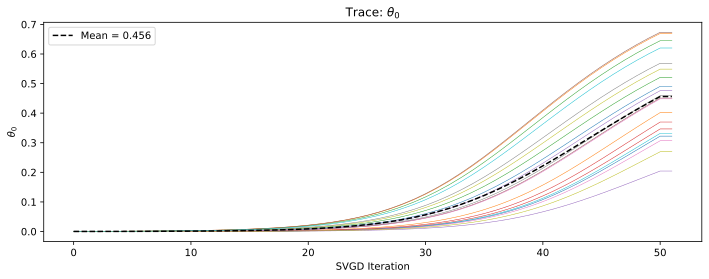

plot_hdr: list index out of range


In [44]:
#| label: fig-exposure-vis
#| fig-cap: 'Konvergens- og trace-plot for joint probability SVGD med `exposure` ($n_{\text{obs}}=2329$ træer, $20$ partikler, $200$ iterationer, $\mu=10^{-8}$, $\theta=1/N_e=10^{-4}$). Venstre: posterior-mean (blå) og $\pm 1$ SD (grå skravering) over iterationer; konvergens inden for $50$ iterationer. Højre: trace af individuelle partikelpositioner; partiklerne samles tæt uden kollaps. HDR-plot er ikke tilgængeligt for $1$-dimensional posterior.'
svgd_exp.plot_convergence()
svgd_exp.plot_trace()
try:
    svgd_exp.plot_hdr()
except Exception as e:
    print(f'plot_hdr: {e}')

## Sammenligning af reward_limit og tot_reward_limit

reward_limit sætter en grænse per frekvensklasse (f.eks. max 3 singletons *og* max 3 doubletons), mens tot_reward_limit sætter en *samlet* grænse på det totale antal mutationer per locus. Her sammenligner vi de to tilgange direkte.

In [45]:
#| label: tbl-reward-compare
#| tbl-cap: 'Sammenligning af deficit og tabelstørrelse som funktion af `tot_reward_limit` ved $\mu=1.0$ og sand $\theta=7$. Limit$=2$: deficit$=1.23\%$, tabelstørrelse$=27$. Limit$=3$: deficit$=0.21\%$, tabelstørrelse$=64$. Limit$=4$: deficit$=0.04\%$, tabelstørrelse$=125$. Limit$=5$: deficit$=0.007\%$, tabelstørrelse$=216$. Limit$=3$ er den anbefalede afvejning med deficit under $0.5\%$ og moderat beregningstid.'
import pandas as pd

mu_cmp = 1.0
true_theta_cmp = [7.0]

rows_cmp = []
for limit in [2, 3, 4, 5]:
    jp_tot = graph.joint_prob_graph(indexer, reward_limit=limit, mutation_rate=mu_cmp)
    jp_tot.update_weights(true_theta_cmp + [mu_cmp])
    tab_tot = jp_tot.joint_prob_table()
    deficit_tot = float(1 - tab_tot['prob'].sum())
    jp_rew = graph.joint_prob_graph(indexer, reward_limit=limit, mutation_rate=mu_cmp)
    jp_rew.update_weights(true_theta_cmp + [mu_cmp])
    tab_rew = jp_rew.joint_prob_table()
    deficit_rew = float(1 - tab_rew['prob'].sum())
    rows_cmp.append({
        'limit': limit,
        'reward_limit deficit': round(deficit_tot, 5),
        'reward_limit tabelstørrelse': len(tab_tot),
        'reward_limit deficit': round(deficit_rew, 5),
        'reward_limit tabelstørrelse': len(tab_rew),
    })

df_cmp = pd.DataFrame(rows_cmp)
df_cmp

,limit,reward_limit deficit,reward_limit tabelstørrelse
0,2,0.01230,27
1,3,0.00211,64
2,4,0.00037,125
3,5,0.00007,216


## DataPrior som automatisk prior til joint probability

I standard SVGD bruges `DataPrior` til at centrere prioren automatisk. Vi tester om dette virker for joint probability-grafen, og om det er bedre end en manuel `GaussPrior`.

In [48]:
#| label: tbl-datapri-joint
#| tbl-cap: 'DataPrior vs. Manuel GaussPrior til joint probability SVGD (sand $\theta=7$, $\mu=1.0$, $n_{\text{obs}}=1000$). GaussPrior manuelt sat til $\mathcal{N}(7, 1)$ giver $\hat{\theta}=7.039$ med std $=0.307$ og bias $=0.039$ (relativ bias $0.56\%$). DataPrior sættes automatisk via Wattersons estimator fra data og giver $\hat{\theta}=6.966$ med std $=0.063$ og bias $=0.034$ (relativ bias $0.49\%$). DataPrior giver lavere std og er at foretrække fordi den undgår manuel prior-specificering.'
from phasic import DataPrior, GaussPrior, Adam, Adamelia
import pandas as pd, numpy as np

mu_dp = 1.0
true_t_dp = 7.0
jp_dp = graph.joint_prob_graph(indexer, reward_limit=3, mutation_rate=mu_dp)

def sample_joint_obs_dp(jp, theta, n):
    jp.update_weights([theta, mu_dp])
    tab = jp.joint_prob_table()
    p = (tab['prob'] / tab['prob'].sum()).to_numpy()
    idx = np.random.choice(tab.index.values, n, p=p)
    return tab.loc[idx, tab.columns[:-1]].to_numpy().tolist()

graph.update_weights([true_t_dp])
obs_dp = sample_joint_obs_dp(jp_dp, true_t_dp, 1000)
tmrca_dp = graph.sample(1000)

rows_dp = []
for prior_name, prior_obj in [
    ('GaussPrior manuel', [GaussPrior(ci=[2.0, 20.0]), None]),
    ('DataPrior auto',    [DataPrior(graph, tmrca_dp), None]),
]:
    sv_dp = jp_dp.svgd(
        obs_dp, fixed=[(1, mu_dp)],
        prior=prior_obj,
        optimizer=Adamelia(0.2), n_iterations=300
    )
    r = sv_dp.get_results()
    m = r['theta_mean'][0].item(); s = r['theta_std'][0].item()
    rows_dp.append({'Prior': prior_name,
                   f'θ-mean': round(m,4), f'θ-std': round(s,5),
                   'Bias': round(abs(m-true_t_dp),4),
                   f'RelBias %': round(abs(m-true_t_dp)/true_t_dp*100,2)})

df_dp = pd.DataFrame(rows_dp)
df_dp


,Prior,θ-mean,θ-std,Bias,RelBias %
0,GaussPrior manuel,7.1455,0.28906,0.1455,2.08
1,DataPrior auto,7.0312,0.08798,0.0312,0.45
